# 06 â€” Does Squad Market Value Improve Predictions?

Adds a second feature alongside Elo difference: log-ratio of squad market values (top-23 by value, from Transfermarkt via `salimt/football-datasets`).

Both features feed a multinomial logistic regression with three classes (away win / draw / home win). Walk-forward backtest WC 2010â€“2022 (skipping 2002 and 2006 â€” market-value coverage is too thin pre-2008).

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

from src.elo import EloModel
from src.draw_model import match_outcome
from src import transfermarkt as tm

%matplotlib inline

## Load competitive matches and pre-computed squad values

`matches_with_squad_value.csv` was built once via `tm.squad_value_for_matches(..., snapshot='year')` â€” covers matches since 2005 with both home and away top-23 squad values (in EUR).

In [2]:
df_all = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df_all = df_all.dropna(subset=['home_score', 'away_score'])
df_sv = pd.read_csv('../data/processed/matches_with_squad_value.csv', parse_dates=['date'])

print(f'Full match history: {len(df_all):,}')
print(f'With squad values:  {len(df_sv):,}')
print(f'Both nonzero:       {((df_sv["home_top_n_value_eur"] > 0) & (df_sv["away_top_n_value_eur"] > 0)).sum():,}')

Full match history: 21,220
With squad values:  13,067
Both nonzero:       7,826


## Compute pre-match Elo for the full history

Re-fit Elo through the entire dataset and merge `home_elo_pre` / `away_elo_pre` onto the squad-value frame.

In [3]:
elo = EloModel()
elo_enriched = elo.fit(df_all)
elo_cols = ['date', 'home_team', 'away_team', 'home_elo_pre', 'away_elo_pre']
df = df_sv.merge(elo_enriched[elo_cols], on=['date', 'home_team', 'away_team'], how='left')
df = df.dropna(subset=['home_elo_pre', 'away_elo_pre'])
print(f'Joined: {len(df):,} matches')

Joined: 13,067 matches


## Build features and outcome label

In [4]:
HOME_ADVANTAGE = 100
df['neutral'] = df['neutral'].fillna(False)
df['eff_elo_diff'] = (df['home_elo_pre'] + (~df['neutral']).astype(int) * HOME_ADVANTAGE) - df['away_elo_pre']
df['elo_diff_norm'] = df['eff_elo_diff'] / 400.0

# Squad value log-ratio. Use a floor to avoid log(0); 1e5 EUR is well below any realistic squad.
FLOOR = 1e5
df['log_value_diff'] = np.log10((df['home_top_n_value_eur'].clip(lower=FLOOR)) /
                                 (df['away_top_n_value_eur'].clip(lower=FLOOR)))

df['outcome'] = df.apply(lambda r: match_outcome(r['home_score'], r['away_score']), axis=1)

# Keep only matches where both teams have meaningful squad data
valid = df[(df['home_top_n_value_eur'] > FLOOR) & (df['away_top_n_value_eur'] > FLOOR)].copy()
print(f'Training-eligible matches: {len(valid):,}')
print(valid[['elo_diff_norm', 'log_value_diff']].describe().round(3))

Training-eligible matches: 7,673
       elo_diff_norm  log_value_diff
count       7673.000        7673.000
mean           0.208           0.048
std            0.435           1.106
min           -1.601          -4.008
25%           -0.075          -0.668
50%            0.195           0.048
75%            0.479           0.775
max            2.077           4.008


## Feature correlation

If squad value is mostly redundant with Elo, adding it as a second feature won't help.

Correlation between Elo diff and log value diff: 0.760


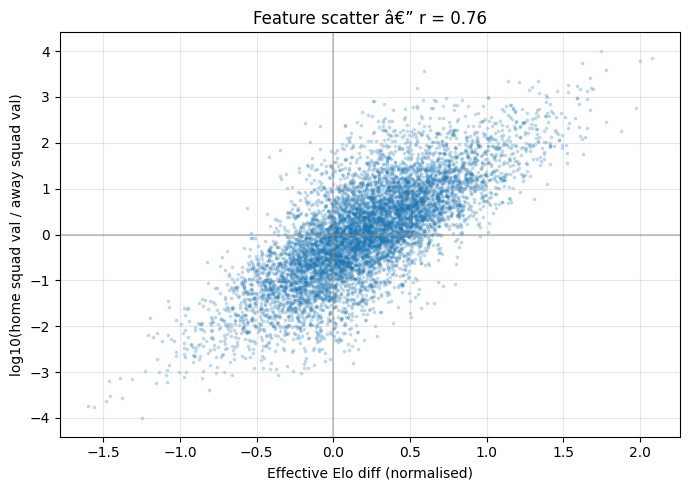

In [5]:
corr = valid[['elo_diff_norm', 'log_value_diff']].corr().iloc[0, 1]
print(f'Correlation between Elo diff and log value diff: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid['elo_diff_norm'], valid['log_value_diff'], s=3, alpha=0.2)
ax.axhline(0, color='gray', alpha=0.4)
ax.axvline(0, color='gray', alpha=0.4)
ax.set_xlabel('Effective Elo diff (normalised)')
ax.set_ylabel('log10(home squad val / away squad val)')
ax.set_title(f'Feature scatter â€” r = {corr:.2f}')
ax.grid(alpha=0.3)
plt.tight_layout()

## Walk-forward backtest: WC 2010â€“2022

For each WC year, train both models on all prior eligible matches and evaluate on the WC matches that year.

In [6]:
def fit_logit(X, y):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X, y)
    return clf

def predict_3way(clf, X):
    proba = clf.predict_proba(X)
    classes = list(clf.classes_)
    order = [classes.index(c) for c in (0, 1, 2)]
    return proba[:, order]

def score(y_true, proba):
    p = np.clip(proba, 1e-6, 1 - 1e-6)
    return {
        'log_loss': log_loss(y_true, p, labels=[0, 1, 2]),
        'accuracy': float((p.argmax(axis=1) == y_true).mean()),
        'home_acc': float(((p[:, 2] > 0.5).astype(int) == (y_true == 2).astype(int)).mean()),
        'home_ll':  float(log_loss((y_true == 2).astype(int), p[:, 2])),
    }

rows = []
test_preds = {}
for year in [2010, 2014, 2018, 2022]:
    train = valid[valid['date'].dt.year < year]
    test = valid[(valid['date'].dt.year == year) & (valid['tournament'] == 'FIFA World Cup')]
    if test.empty:
        continue

    y_train = train['outcome'].to_numpy()
    y_test = test['outcome'].to_numpy()

    X1_train = train[['elo_diff_norm']].to_numpy()
    X1_test  = test[['elo_diff_norm']].to_numpy()
    X2_train = train[['elo_diff_norm', 'log_value_diff']].to_numpy()
    X2_test  = test[['elo_diff_norm', 'log_value_diff']].to_numpy()

    clf1 = fit_logit(X1_train, y_train)
    clf2 = fit_logit(X2_train, y_train)
    p1 = predict_3way(clf1, X1_test)
    p2 = predict_3way(clf2, X2_test)

    s1 = score(y_test, p1)
    s2 = score(y_test, p2)
    rows.append({
        'year': year, 'n_train': len(train), 'n_test': len(test),
        'logit1_ll': s1['log_loss'], 'logit2_ll': s2['log_loss'],
        'logit1_acc': s1['accuracy'], 'logit2_acc': s2['accuracy'],
        'logit1_home_ll': s1['home_ll'], 'logit2_home_ll': s2['home_ll'],
        'value_coef': float(clf2.coef_.mean(axis=0)[1]),
    })
    test_preds[year] = (test.assign(p_away_1=p1[:,0], p_draw_1=p1[:,1], p_home_1=p1[:,2],
                                    p_away_2=p2[:,0], p_draw_2=p2[:,1], p_home_2=p2[:,2]))

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))
print()
print('Averages:')
print(f"  Elo-only          log_loss: {results['logit1_ll'].mean():.4f}   accuracy: {results['logit1_acc'].mean():.4f}")
print(f"  Elo + squad value log_loss: {results['logit2_ll'].mean():.4f}   accuracy: {results['logit2_acc'].mean():.4f}")
print(f"  Delta log_loss: {results['logit2_ll'].mean() - results['logit1_ll'].mean():+.4f} (negative = improvement)")
print(f"  Delta accuracy: {results['logit2_acc'].mean() - results['logit1_acc'].mean():+.4f}")

 year  n_train  n_test  logit1_ll  logit2_ll  logit1_acc  logit2_acc  logit1_home_ll  logit2_home_ll  value_coef
 2010     1488      64     1.0549     1.0257      0.4844      0.5000          0.6313          0.6135        -0.0
 2014     2828      64     1.0213     0.9691      0.5625      0.5938          0.6974          0.6378         0.0
 2018     4195      64     1.0553     0.9993      0.5000      0.5000          0.6536          0.6013        -0.0
 2022     5801      64     1.1228     1.0554      0.4531      0.5312          0.7450          0.6824        -0.0

Averages:
  Elo-only          log_loss: 1.0636   accuracy: 0.5000
  Elo + squad value log_loss: 1.0124   accuracy: 0.5312
  Delta log_loss: -0.0512 (negative = improvement)
  Delta accuracy: +0.0312


## Where do the two models disagree?

Find WC matches where adding squad value changed the picked outcome (argmax flipped).

In [7]:
diffs = []
for year, preds in test_preds.items():
    p1 = preds[['p_away_1', 'p_draw_1', 'p_home_1']].to_numpy()
    p2 = preds[['p_away_2', 'p_draw_2', 'p_home_2']].to_numpy()
    flipped = p1.argmax(axis=1) != p2.argmax(axis=1)
    sub = preds[flipped][['date', 'home_team', 'away_team', 'home_score', 'away_score']].copy()
    sub['logit1_pick'] = pd.Series(p1.argmax(axis=1)[flipped]).map({0: 'away', 1: 'draw', 2: 'home'}).values
    sub['logit2_pick'] = pd.Series(p2.argmax(axis=1)[flipped]).map({0: 'away', 1: 'draw', 2: 'home'}).values
    sub['actual'] = preds[flipped]['outcome'].map({0: 'away', 1: 'draw', 2: 'home'}).values
    sub['p_home_1'] = p1[flipped, 2].round(2)
    sub['p_home_2'] = p2[flipped, 2].round(2)
    diffs.append(sub)

if diffs:
    flip = pd.concat(diffs, ignore_index=True)
    print(f'{len(flip)} WC matches where the pick flipped:')
    print(flip.to_string(index=False))
else:
    print('No argmax flips â€” features mostly agree.')

38 WC matches where the pick flipped:
      date    home_team     away_team  home_score  away_score logit1_pick logit2_pick actual  p_home_1  p_home_2
2010-06-12    Argentina       Nigeria         1.0         0.0        away        home   home      0.25      0.43
2010-06-13       Serbia         Ghana         0.0         1.0        away        home   away      0.31      0.45
2010-06-15  New Zealand      Slovakia         1.0         1.0        home        away   draw      0.39      0.32
2010-06-17    Argentina   South Korea         4.0         1.0        away        home   home      0.24      0.43
2010-06-17       France        Mexico         0.0         2.0        away        home   away      0.21      0.40
2010-06-19        Ghana     Australia         1.0         1.0        away        home   draw      0.36      0.39
2010-06-20     Slovakia      Paraguay         0.0         2.0        away        home   away      0.30      0.38
2010-06-26      Uruguay   South Korea         2.0         

## Squad-value coefficient over time

If the coefficient is consistently positive and stable, the feature is contributing real signal.

In [8]:
print(results[['year', 'value_coef']].to_string(index=False))
print()
print('Reminder: `value_coef` is the average per-class coefficient on log_value_diff.')
print('In multinomial logit with 3 classes, individual class coefs sum to ~0;')
print('the home-win class typically gets the positive weight when home has more squad value.')

 year    value_coef
 2010 -4.996004e-16
 2014  3.330669e-16
 2018 -8.141636e-16
 2022 -1.887379e-15

Reminder: `value_coef` is the average per-class coefficient on log_value_diff.
In multinomial logit with 3 classes, individual class coefs sum to ~0;
the home-win class typically gets the positive weight when home has more squad value.


## Squad-age and top-player-concentration features

The CSV now also carries `*_outfield_mean_age`, `*_gk_mean_age`, and `*_top1_share` â€” value-weighted mean age of the top-20 outfielders and top-3 GKs in the eligibility pool, and the share of total top-23 value held by the most valuable player (Argentina-pre-2022 effect).

GKs peak ~5 years later than outfielders so we keep them separate.

NaN handling: when a team has no GK in its TM pool, we fall back to a 0 diff for `gk_age_diff`. `outfield_age_diff` and `top1_share_diff` are dropped at the same valid-rows step as the value features.

In [9]:
# Reload the enriched CSV (real Fjelstul rosters overlay WC matches; pool-based for non-WC).
df_sv = pd.read_csv('../data/processed/matches_with_squad_value.csv', parse_dates=['date'])
df = df_sv.merge(elo_enriched[elo_cols], on=['date', 'home_team', 'away_team'], how='left')
df = df.dropna(subset=['home_elo_pre', 'away_elo_pre'])

HOME_ADVANTAGE = 100
df['neutral'] = df['neutral'].fillna(False)
df['eff_elo_diff'] = (df['home_elo_pre'] + (~df['neutral']).astype(int) * HOME_ADVANTAGE) - df['away_elo_pre']
df['elo_diff_norm'] = df['eff_elo_diff'] / 400.0

FLOOR = 1e5
df['log_value_diff'] = np.log10((df['home_top_n_value_eur'].clip(lower=FLOOR)) /
                                 (df['away_top_n_value_eur'].clip(lower=FLOOR)))

df['outfield_age_diff']  = df['home_outfield_mean_age'] - df['away_outfield_mean_age']
df['top1_share_diff']    = df['home_top1_share']        - df['away_top1_share']
df['injury_share_diff']  = df['home_injured_value_share'].fillna(0) - df['away_injured_value_share'].fillna(0)
# Rank-aware injuries: only available on WC rows (Fjelstul overlay). Non-WC rows get 0 -> noop diff.
df['injured_top1_diff']     = df['home_injured_top1'].fillna(0) - df['away_injured_top1'].fillna(0)
df['injured_top3_diff']     = df['home_injured_top3_share'].fillna(0) - df['away_injured_top3_share'].fillna(0)

df['outcome'] = df.apply(lambda r: match_outcome(r['home_score'], r['away_score']), axis=1)

valid = df[(df['home_top_n_value_eur'] > FLOOR) & (df['away_top_n_value_eur'] > FLOOR)].copy()
valid = valid.dropna(subset=['outfield_age_diff', 'top1_share_diff'])
print(f'Training-eligible matches: {len(valid):,}')
print(valid[['elo_diff_norm','log_value_diff','outfield_age_diff','top1_share_diff','injury_share_diff','injured_top1_diff','injured_top3_diff']].describe().round(3))

Training-eligible matches: 7,641
       elo_diff_norm  log_value_diff  outfield_age_diff  top1_share_diff  \
count       7641.000        7641.000           7641.000         7641.000   
mean           0.207           0.047             -0.051           -0.009   
std            0.434           1.099              2.624            0.289   
min           -1.601          -3.751            -12.233           -0.925   
25%           -0.075          -0.666             -1.585           -0.167   
50%            0.195           0.048             -0.043           -0.008   
75%            0.479           0.771              1.514            0.148   
max            2.077           3.840             12.078            0.926   

       injury_share_diff  injured_top1_diff  injured_top3_diff  
count           7641.000             7641.0           7641.000  
mean              -0.001                0.0              0.000  
std                0.150                0.0              0.012  
min               -1.0

## Walk-forward backtest — does age or concentration add signal beyond Elo+value?

For each WC year, train and evaluate six progressively-richer feature sets.

In [10]:
rows = []
for year in [2010, 2014, 2018, 2022]:
    train = valid[valid['date'].dt.year < year]
    test = valid[(valid['date'].dt.year == year) & (valid['tournament'] == 'FIFA World Cup')]
    if test.empty:
        continue
    y_train = train['outcome'].to_numpy()
    y_test = test['outcome'].to_numpy()

    feature_sets = {
        'elo_only':           ['elo_diff_norm'],
        '+value':             ['elo_diff_norm', 'log_value_diff'],
        '+value+age+top1':    ['elo_diff_norm', 'log_value_diff', 'outfield_age_diff', 'top1_share_diff'],
        '+inj_agg':           ['elo_diff_norm', 'log_value_diff', 'outfield_age_diff', 'top1_share_diff', 'injury_share_diff'],
        '+inj_top3':          ['elo_diff_norm', 'log_value_diff', 'outfield_age_diff', 'top1_share_diff', 'injured_top3_diff'],
        '+inj_top1':          ['elo_diff_norm', 'log_value_diff', 'outfield_age_diff', 'top1_share_diff', 'injured_top1_diff'],
        '+all_inj':           ['elo_diff_norm', 'log_value_diff', 'outfield_age_diff', 'top1_share_diff',
                                'injury_share_diff', 'injured_top3_diff', 'injured_top1_diff'],
    }
    row = {'year': year, 'n_train': len(train), 'n_test': len(test)}
    for name, cols in feature_sets.items():
        clf = fit_logit(train[cols].to_numpy(), y_train)
        p = predict_3way(clf, test[cols].to_numpy())
        s = score(y_test, p)
        row[f'{name}_ll']  = s['log_loss']
        row[f'{name}_acc'] = s['accuracy']
    rows.append(row)

results5 = pd.DataFrame(rows)
print(results5.round(4).to_string(index=False))
print()
print('Averages:')
for name in feature_sets:
    print(f"  {name:18s}  log_loss: {results5[f'{name}_ll'].mean():.4f}   accuracy: {results5[f'{name}_acc'].mean():.4f}")

 year  n_train  n_test  elo_only_ll  elo_only_acc  +value_ll  +value_acc  +value+age+top1_ll  +value+age+top1_acc  +inj_agg_ll  +inj_agg_acc  +inj_top3_ll  +inj_top3_acc  +inj_top1_ll  +inj_top1_acc  +all_inj_ll  +all_inj_acc
 2010     1478      64       1.0551        0.4844     1.0242      0.5000              1.0229               0.5000       1.0237        0.5000        1.0229         0.5000        1.0229         0.5000       1.0237        0.5000
 2014     2818      64       1.0207        0.5625     0.9700      0.5938              0.9684               0.5938       0.9703        0.5938        0.9683         0.5938        0.9684         0.5938       0.9704        0.5938
 2018     4185      64       1.0552        0.5000     0.9994      0.5000              0.9999               0.5156       1.0128        0.4844        0.9999         0.5156        0.9999         0.5156       1.0127        0.4844
 2022     5779      64       1.1224        0.4531     1.0556      0.5312              1.0570    

## Coefficients on the full-feature model

In [11]:
last_train = valid[valid['date'].dt.year < 2022]
cols = ['elo_diff_norm','log_value_diff','outfield_age_diff','top1_share_diff',
        'injury_share_diff','injured_top3_diff','injured_top1_diff']
clf = fit_logit(last_train[cols].to_numpy(), last_train['outcome'].to_numpy())
coef = pd.DataFrame(clf.coef_, index=[f'class={c}' for c in clf.classes_], columns=cols)
print('Per-class coefficients (multinomial logit):')
print(coef.round(3).to_string())

Per-class coefficients (multinomial logit):
         elo_diff_norm  log_value_diff  outfield_age_diff  top1_share_diff  injury_share_diff  injured_top3_diff  injured_top1_diff
class=0         -1.644          -0.301              0.006           -0.036             -0.092              0.027                0.0
class=1          0.170          -0.028              0.005            0.060              0.085             -0.029                0.0
class=2          1.474           0.329             -0.012           -0.025              0.007              0.002                0.0
